<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_5_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

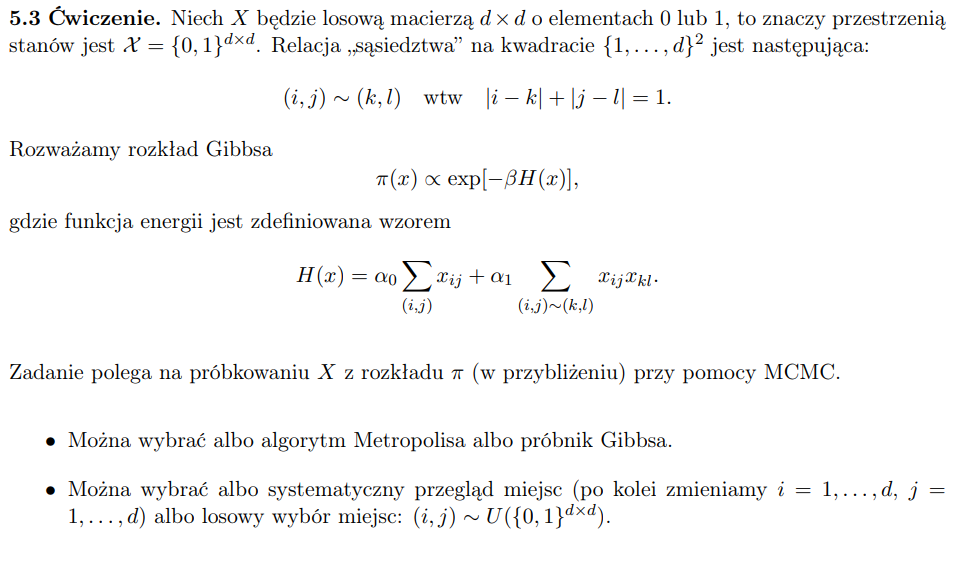

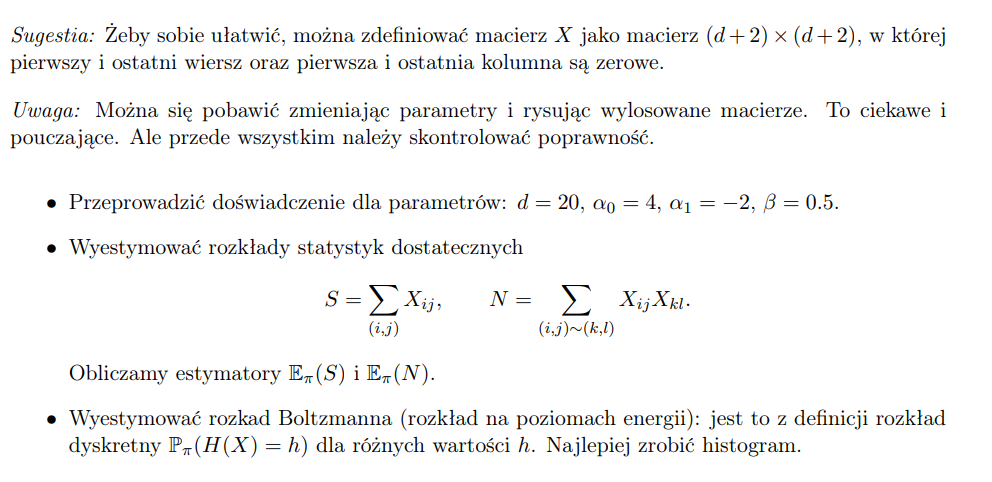

## Gibbs Sampler Implementation
To update a single cell $x_{ij}$, we compute its local conditional probability. Let $z_{ij}$ be the sum of its four immediate neighbors:
$$z_{ij} = x_{i-1,j} + x_{i+1,j} + x_{i,j-1} + x_{i,j+1}$$

The local change in energy if $x_{ij} = 1$ (compared to $x_{ij} = 0$) is exactly the cost of the main effect plus the interaction with its current neighbors:
$$\Delta H_{ij} = \alpha_0 + \alpha_1 z_{ij}$$

Using the Gibbs distribution formula, the conditional probability simplifies to the logistic function:
$$P(x_{ij} = 1 | \text{neighbors}) = \frac{\exp(-\beta \Delta H_{ij})}{\exp(-\beta \Delta H_{ij}) + \exp(0)} = \frac{1}{1 + \exp(\beta (\alpha_0 + \alpha_1 z_{ij}))}$$

## Simulations
---

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# setup
np.random.seed(42)
d = 20
alpha_0 = 4.0
alpha_1 = -2.0
beta = 0.5

In [8]:
# helper functions

def compute_S_N(X):
    """Returns S (sum of ones) and N (number of pairs)."""
    core = X[1:-1, 1:-1]
    S = np.sum(core)
    # we count pairs (of ones) only to the right and down to avoid counting the same pair two times
    N = np.sum(core * X[1:-1, 2:]) + np.sum(core * X[2:, 1:-1])
    return S, N

def compute_H(S, N):
    """Computes total energy H(x)."""
    return alpha_0 * S + alpha_1 * N

In [9]:
# simulations

# initialization: (d+2) x (d+2) matrix with zeros
X = np.zeros((d + 2, d + 2), dtype=int)

# generating random initial X
X[1:-1, 1:-1] = np.random.binomial(1, 0.5, size=(d, d))

n = 20000
burn_in = 100000

# arrays for tracking
S_history = []
N_history = []
H_history = []


for _ in range(n):
    # generating d*d random coordinates to visit
    i_coords = np.random.randint(1, d + 1, size=d * d)
    j_coords = np.random.randint(1, d + 1, size=d * d)

    # iterating through these d*d random coordinates
    for i, j in zip(i_coords, j_coords):
        # sum of neighbours
        z = X[i-1, j] + X[i+1, j] + X[i, j-1] + X[i, j+1]

        # calculating energy difference and probability
        delta_H = alpha_0 + alpha_1 * z
        prob_1 = 1.0 / (1.0 + np.exp(beta * delta_H))

        # change of state with above probability
        X[i, j] = np.random.binomial(1, prob_1)

        # saving state after full cycle
        S, N_val = compute_S_N(X)
        H = compute_H(S, N_val)

        S_history.append(S)
        N_history.append(N_val)
        H_history.append(H)



# deleting burn-in
S_samples = np.array(S_history[burn_in:])
N_samples = np.array(N_history[burn_in:])
H_samples = np.array(H_history[burn_in:])

In [11]:
burn_in = 500000


In [12]:
# deleting burn-in
S_samples = np.array(S_history[burn_in:])
N_samples = np.array(N_history[burn_in:])
H_samples = np.array(H_history[burn_in:])

Estimated E[S] (Average number of ones): 174.23
Estimated E[N] (Average number of pairs of ones): 202.50


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


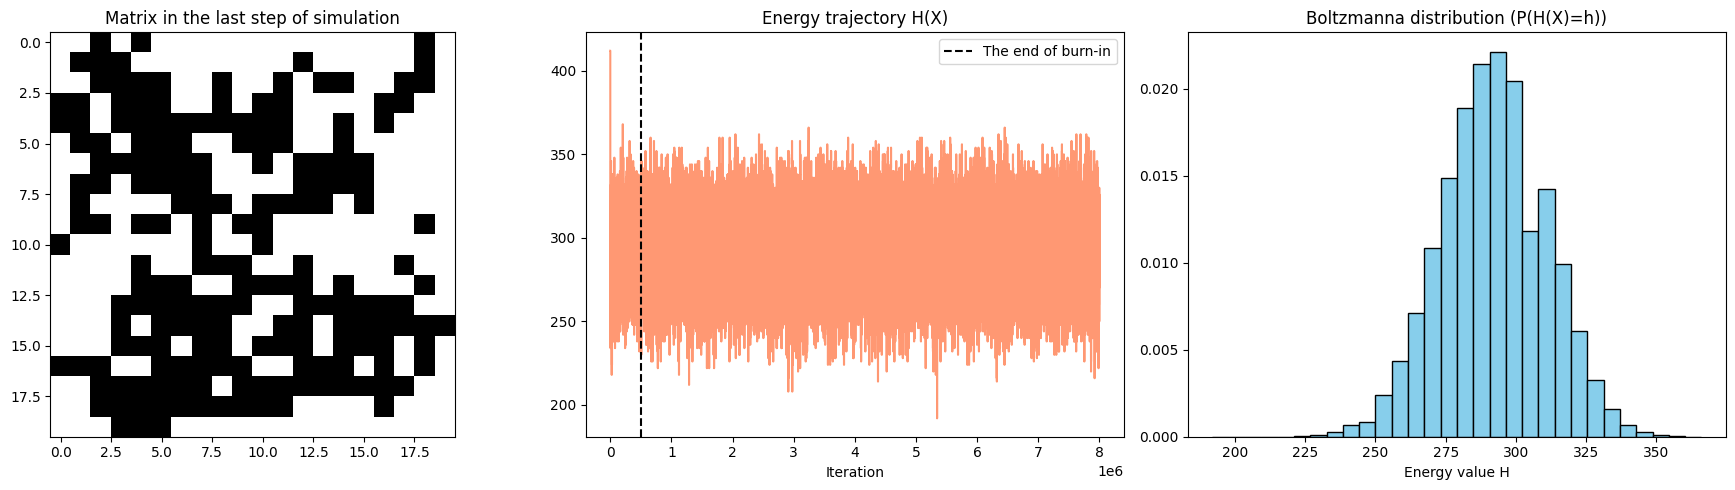

In [13]:
# results and visualizations
E_S = np.mean(S_samples)
E_N = np.mean(N_samples)

print(f"Estimated E[S] (Average number of ones): {E_S:.2f}")
print(f"Estimated E[N] (Average number of pairs of ones): {E_N:.2f}")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1. Exemplary matrix - the one in the last step
axs[0].imshow(X[1:-1, 1:-1], cmap='Greys', interpolation='nearest')
axs[0].set_title("Matrix in the last step of simulation")
axs[0].grid(False)

# Plot 2. Energy trajectory
axs[1].plot(H_history, color='coral', alpha=0.8)
axs[1].axvline(burn_in, color='black', linestyle='--', label='The end of burn-in')
axs[1].set_title("Energy trajectory H(X)")
axs[1].set_xlabel("Iteration")
axs[1].legend()

# Plot 3. Boltzmanna distribution
axs[2].hist(H_samples, bins=30, color='skyblue', edgecolor='black', density=True)
axs[2].set_title("Boltzmanna distribution (P(H(X)=h))")
axs[2].set_xlabel("Energy value H")

plt.tight_layout()
plt.show()